In [1]:
from chipanalysis.utils.file_reader import load_czi_2d,_squeeze_to_2d,stretch_contrast
from pathlib import Path
from aicspylibczi import CziFile
import matplotlib.pyplot as plt
import numpy as np
%matplotlib widget


In [2]:
root_path = "/home/bisot/shares/van_gestel_server/ZeissData/slugs"
czi_name = "slugcrossing.czi"

czi_path = Path(root_path,czi_name)
czi = CziFile(czi_path)

dims = czi.dims
sizes = czi.size

dim_sizes = dict(zip(dims, sizes))
dim_sizes["T"]


115

In [3]:
import numpy as np

def get_frame(
    czi,
    time,
    channel,
    gamma=1.0,
    roi=None,
    scale_factor=1.0
):
    """
    Load a frame from a CZI mosaic.
    
    Parameters
    ----------
    roi : dict or None
        {"x0","y0","x1","y1"} in FULL-RES pixel coordinates
    scale_factor : float
        Same scale_factor used in read_mosaic()
    """

    mosaic = czi.read_mosaic(
        C=channel,
        T=time,
        scale_factor=scale_factor
    )

    img = _squeeze_to_2d(mosaic).astype(np.float32)

    # --- Apply ROI if provided ---
    if roi is not None:
        # Convert ROI from full-res to current scale
        x0 = int(round(roi["x0"] * scale_factor))
        x1 = int(round(roi["x1"] * scale_factor))
        y0 = int(round(roi["y0"] * scale_factor))
        y1 = int(round(roi["y1"] * scale_factor))

        # Clamp to image bounds
        h, w = img.shape
        x0, x1 = np.clip([x0, x1], 0, w)
        y0, y1 = np.clip([y0, y1], 0, h)

        img = img[y0:y1, x0:x1]

    # --- Display-only contrast ---
    img_disp = stretch_contrast(img, 1, 99)

    if gamma != 1.0:
        img_disp = np.clip(img_disp, 0, 1) ** gamma

    return img, img_disp


In [4]:
channel = 1
time = 100
img, img_disp = get_frame(czi,time,channel)

In [5]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.widgets import RectangleSelector

# img_disp should be a 2D array you display (e.g. contrast-stretched)
# If you already have `img` from the CZI loader, do:
# img_disp = stretch_contrast(img, 1, 99)

# roi = {"x0": None, "y0": None, "x1": None, "y1": None}

# fig, ax = plt.subplots(figsize=(8, 8))
# ax.imshow(img_disp, cmap="gray", vmin=0, vmax=1)
# ax.set_title("Drag to select ROI. Press Enter to accept, Esc to clear.")
# ax.set_axis_off()

# def onselect(eclick, erelease):
#     eclick and erelease are matplotlib events at press and release
#     x0, y0 = float(eclick.xdata), float(eclick.ydata)
#     x1, y1 = float(erelease.xdata), float(erelease.ydata)

#     Normalize order so x0<x1, y0<y1
#     x0, x1 = sorted([x0, x1])
#     y0, y1 = sorted([y0, y1])

#     roi.update({"x0": x0, "y0": y0, "x1": x1, "y1": y1})
#     print("ROI:", roi)

# rect_selector = RectangleSelector(
#     ax,
#     onselect,
#     useblit=True,
#     button=[1],          # left mouse button
#     interactive=True,    # allow resizing/moving after draw
#     minspanx=5,
#     minspany=5,
#     spancoords="pixels",
# )

# def on_key(event):
#     if event.key == "enter":
#         print("Accepted ROI:", roi)
#     elif event.key == "escape":
#         rect_selector.set_visible(False)
#         rect_selector.set_visible(True)  # quick clear/redraw
#         roi.update({"x0": None, "y0": None, "x1": None, "y1": None})
#         fig.canvas.draw_idle()
#         print("Cleared ROI")

# fig.canvas.mpl_connect("key_press_event", on_key)
# plt.show()


In [6]:
roi_saved = roi

NameError: name 'roi' is not defined

In [7]:
roi_saved = {'x0': 50.77272727272748,
 'y0': 2449.603896103896,
 'x1': 1995.4740259740256,
 'y1': 6009.396103896104}

In [86]:
channel = 1
time = 110
img, img_disp = get_frame(czi,time,channel,roi=roi_saved,gamma=1)

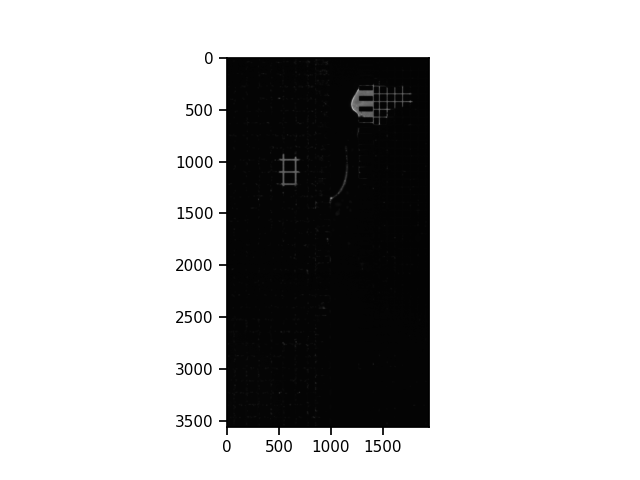

In [87]:
fig,ax = plt.subplots()
ax.imshow(img,cmap="gray")

In [88]:
import numpy as np
import cv2

def log_image(gray, sigma=1.5):
    gray = gray.astype(np.float32)

    # let OpenCV pick kernel size from sigma
    blurred = cv2.GaussianBlur(gray, ksize=(0, 0), sigmaX=sigma, sigmaY=sigma)

    # Laplacian (second derivative)
    log = cv2.Laplacian(blurred, ddepth=cv2.CV_32F, ksize=3)
    return log

def hessian_det_blob_cv2(gray, sigma=1.6):
    I = gray.astype(np.float32)

    # Smooth at scale sigma
    S = cv2.GaussianBlur(I, (0, 0), sigmaX=sigma, sigmaY=sigma)

    # Second derivatives (Sobel 2nd order)
    Ixx = cv2.Sobel(S, cv2.CV_32F, dx=2, dy=0, ksize=3)
    Iyy = cv2.Sobel(S, cv2.CV_32F, dx=0, dy=2, ksize=3)
    Ixy = cv2.Sobel(S, cv2.CV_32F, dx=1, dy=1, ksize=3)

    # Scale-normalization (important for multi-scale blob detection)
    s2 = sigma * sigma
    Ixx *= s2; Iyy *= s2; Ixy *= s2

    detH = Ixx * Iyy - Ixy * Ixy            # = λ1 * λ2
    trace = Ixx + Iyy                       # = λ1 + λ2

    # If you want bright blobs on dark background:
    detH = np.where(trace < 0, detH, 0.0)

    return detH, trace, (Ixx, Iyy, Ixy)

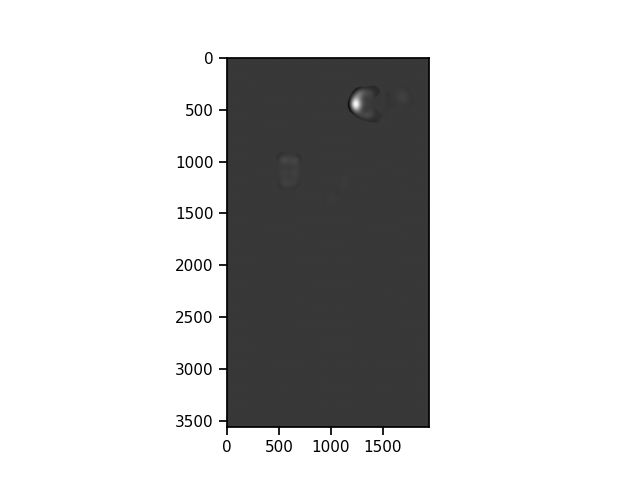

In [90]:
fig,ax = plt.subplots()
ax.imshow(hessian_det_blob_cv2(img,60)[0],cmap="gray")

In [ ]:
import pandas as pd
import numpy as np




def compute_profiles_over_time_wide(
    czi,
    times,
    channel,
    roi=None,
    metrics=None
):
    """
    Returns DataFrame with columns:
      t, x, <metric1>, <metric2>, ...
    """
    if metrics is None:
        metrics = {"mean": profile_mean}

    frames = []

    for t in times:
        img, _ = get_frame(czi, t, channel, roi=roi, gamma=1)

        x = np.arange(img.shape[1])
        row = {"t": t, "x": x}

        for name, fn in metrics.items():
            y = fn(img)
            if y.shape[0] != x.shape[0]:
                raise ValueError(f"Metric '{name}' returned shape {y.shape}, expected (X,)")
            row[name] = y

        frames.append(pd.DataFrame(row))

    return pd.concat(frames, ignore_index=True)

In [78]:
def profile_mean(img):      return np.mean(img, axis=0)
def profile_blob(img):      return np.mean(hessian_det_blob_cv2(img,40)[0], axis=0)
def profile_blob20(img):      return np.mean(hessian_det_blob_cv2(img,20)[0], axis=0)
def profile_blob60(img):      return np.mean(hessian_det_blob_cv2(img,60)[0], axis=0)




times = list(range(0, dim_sizes["T"], 5))

metrics = {
    "mean": profile_mean,
    "profile_blob": profile_blob,
    "profile_blob20": profile_blob20,
    "profile_blob60": profile_blob60,


}

df = compute_profiles_over_time_wide(czi, times, channel, roi=roi_saved, metrics=metrics)
df.head()


,t,x,mean,profile_blob,profile_blob20,profile_blob60
0,0,0,112.691765,-35.439892,153.264297,19.177959
1,0,1,112.727173,-35.230431,152.651703,20.065166
2,0,2,112.559425,-35.629196,151.799896,18.986097
3,0,3,112.626579,-35.837242,149.714859,19.721657
4,0,4,113.429893,-35.810001,146.089600,19.448414


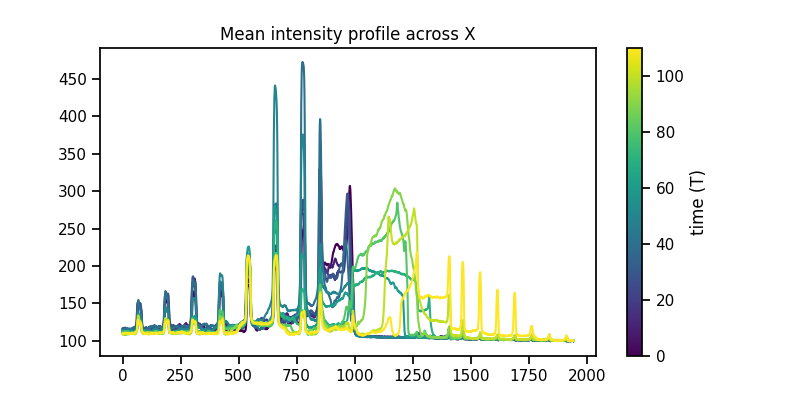

In [51]:
fig, ax = plt.subplots(figsize=(8,4))
cmap = plt.get_cmap("viridis")
norm = plt.Normalize(df["t"].min(), df["t"].max())

for t, g in df.groupby("t"):
    ax.plot(g["x"], g["mean"], color=cmap(norm(t)))

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="time (T)")
ax.set_title("Mean intensity profile across X")
plt.show()


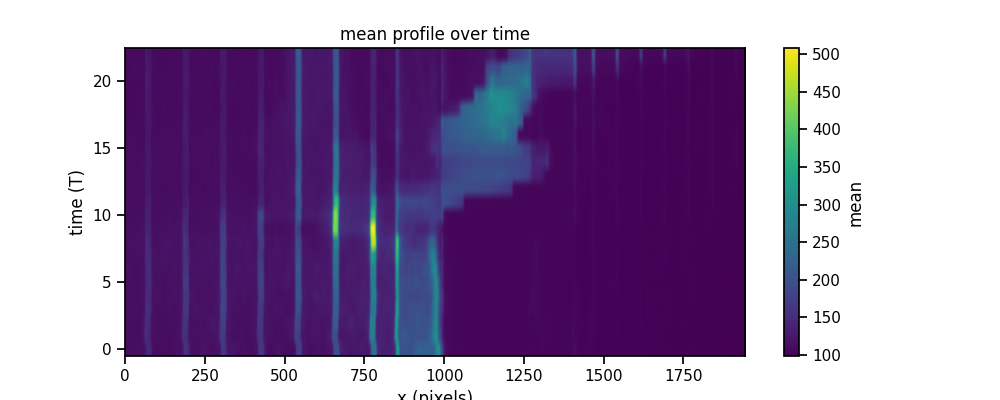

In [91]:
metric = "mean"
pivot = df.pivot(index="t", columns="x", values=metric)

plt.figure(figsize=(10,4))
plt.imshow(pivot.values, aspect="auto", origin="lower")
plt.colorbar(label=metric)
plt.xlabel("x (pixels)")
plt.ylabel("time (T)")
plt.title(f"{metric} profile over time")
plt.show()


In [84]:
metric = "profile_blob60"   # or "std", "p90", etc.

df_time = (
    df.groupby("t", as_index=False)[metric]
      .mean()
)


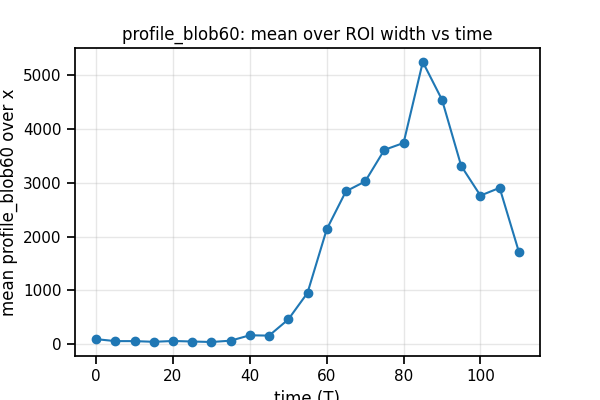

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(df_time["t"], df_time[f"{metric}"], marker="o")
plt.xlabel("time (T)")
plt.ylabel(f"mean {metric} over x")
plt.title(f"{metric}: mean over ROI width vs time")
plt.grid(True, alpha=0.3)
plt.show()
